--- 📊 RESUMEN ESTADÍSTICO DE VARIABLES CLAVE ---
           Precio  Superficie_Construida  Habitaciones    Banos   Planta
count     1887.00                1887.00       1887.00  1887.00  1887.00
mean    478439.11                 127.25          3.09     1.78     3.30
std     376891.31                 105.43          1.25     0.95     2.81
min     100000.00                  26.00          1.00     1.00     0.00
25%     250000.00                  80.00          2.00     1.00     1.00
50%     360000.00                 104.00          3.00     2.00     3.00
75%     595000.00                 141.00          4.00     2.00     5.00
max    4700000.00                3197.00         16.00    16.00    20.00

--- 🔗 CORRELACIÓN CON EL PRECIO ---
Precio                   1.000000
Banos                    0.717719
Superficie_Util          0.669177
Superficie_Construida    0.590477
Habitaciones             0.459575
Garaje                   0.200263
Terraza                  0.199013
Ascensor           

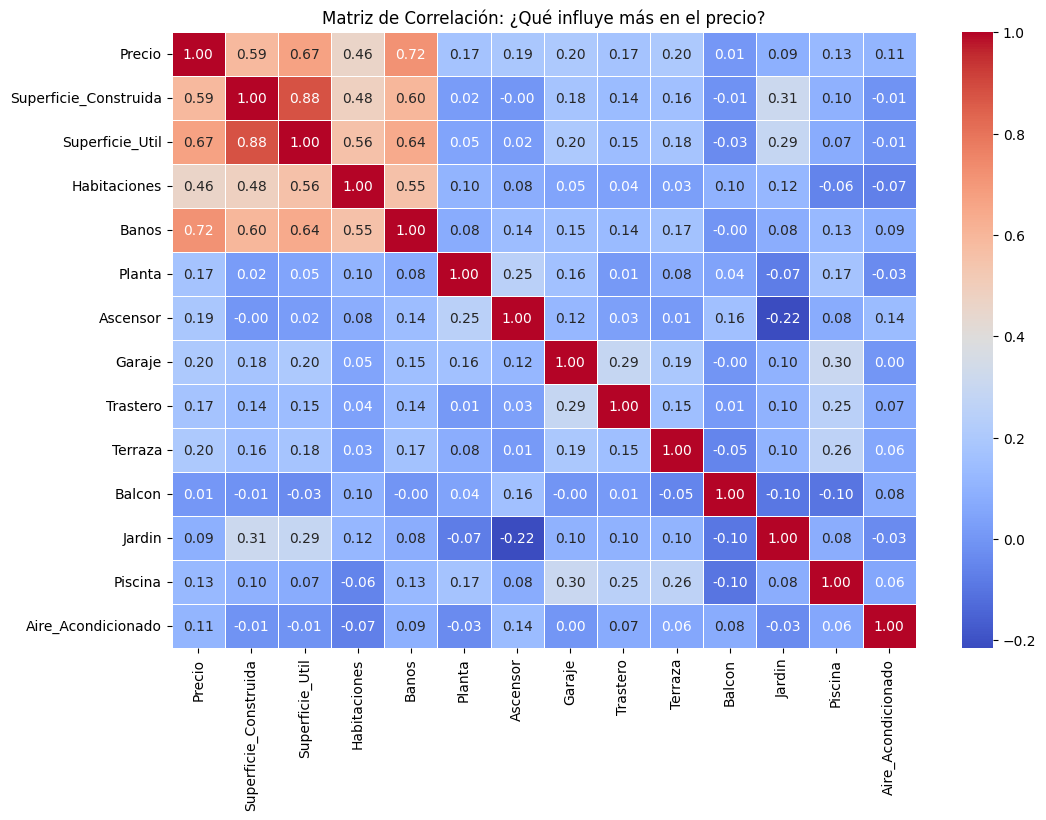

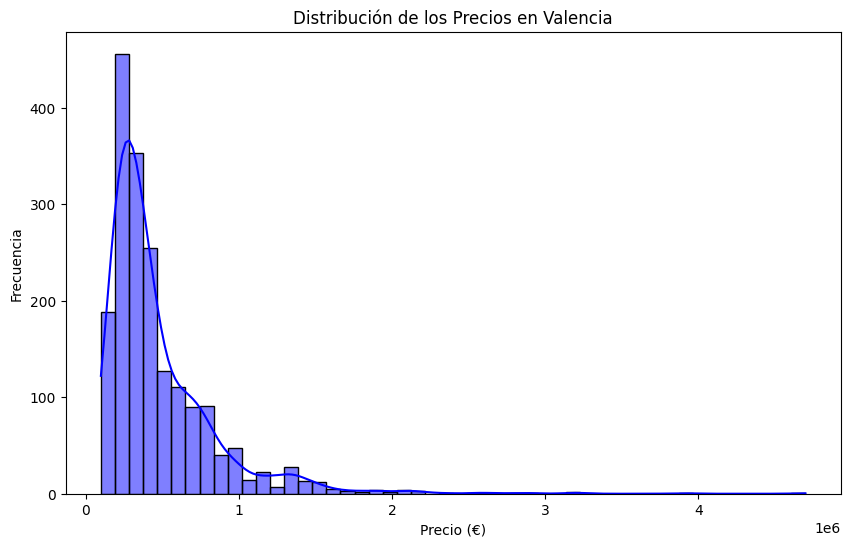

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Cargamos el último dataset guardado
df = pd.read_csv('dataset_VALENCIA_ZONIFICADO.csv', sep=';', decimal=',')

print("--- 📊 RESUMEN ESTADÍSTICO DE VARIABLES CLAVE ---")
variables_interes = ['Precio', 'Superficie_Construida', 'Habitaciones', 'Banos', 'Planta']
print(df[variables_interes].describe().round(2))

# 2. CÁLCULO DE CORRELACIONES (Pearson)
# Queremos ver qué variables están más "pegadas" al precio
print("\n--- 🔗 CORRELACIÓN CON EL PRECIO ---")
# Solo calculamos correlación para columnas numéricas
corr_matrix = df_num.select_dtypes(include=[np.number]).corr()
print(corr_matrix['Precio'].sort_values(ascending=False))

# 3. VISUALIZACIÓN: Mapa de Calor
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación: ¿Qué influye más en el precio?')
plt.show()

# 4. VISUALIZACIÓN: Distribución del Precio (Histograma)
plt.figure(figsize=(10, 6))
sns.histplot(df['Precio'], kde=True, color='blue', bins=50)
plt.title('Distribución de los Precios en Valencia')
plt.xlabel('Precio (€)')
plt.ylabel('Frecuencia')
plt.show()

--- 📊 RESUMEN ESTADÍSTICO TRAS LIMPIEZA ---


,Precio,Superficie_Construida,Habitaciones,Banos,Planta
count,1857.00,1857.00,1857.00,1857.00,1857.00
mean,461524.82,120.53,3.04,1.73,3.32
std,321420.06,63.92,1.13,0.79,2.81
min,100000.00,26.00,1.00,1.00,0.00
25%,250000.00,80.00,2.00,1.00,1.00
50%,350000.00,103.00,3.00,2.00,3.00
75%,585000.00,140.00,4.00,2.00,5.00
max,2350000.00,480.00,7.00,6.00,20.00


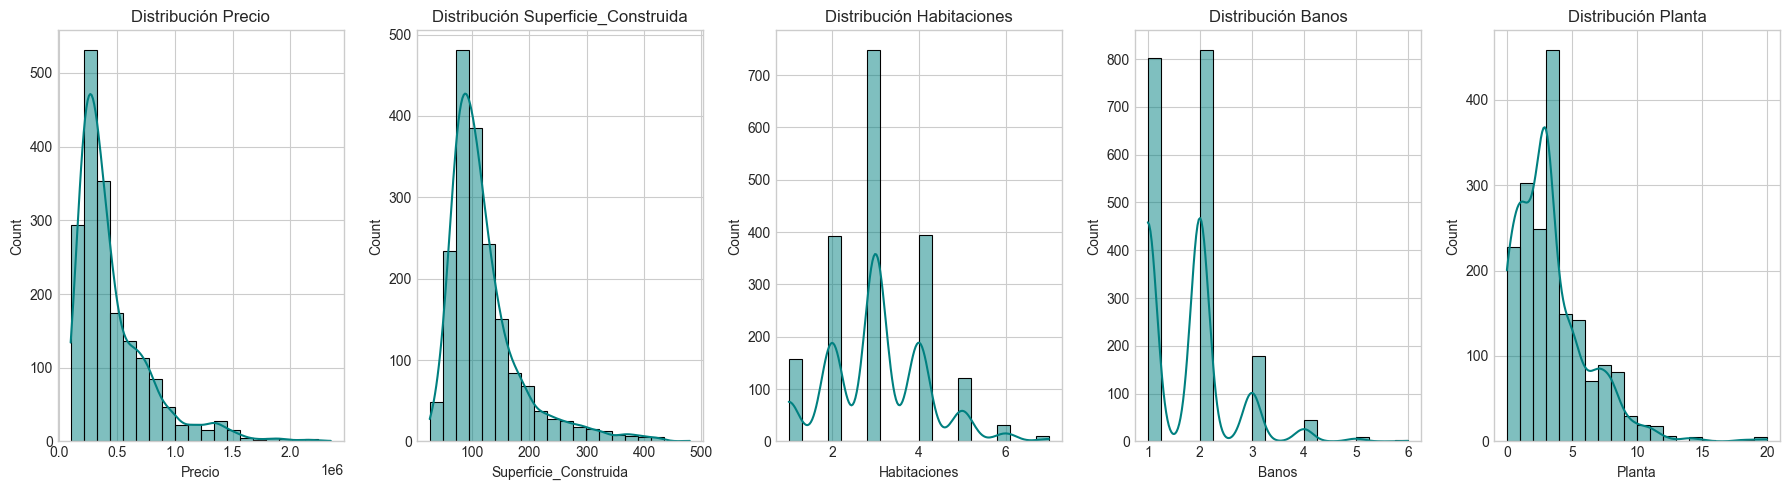

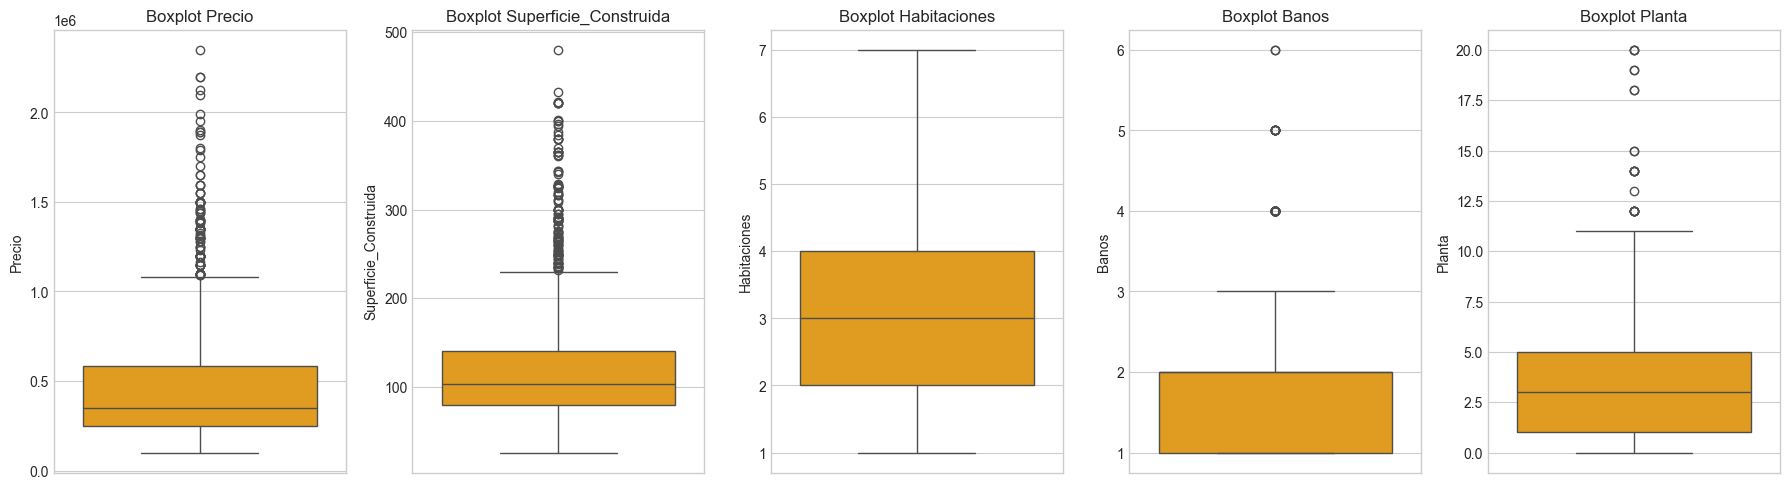

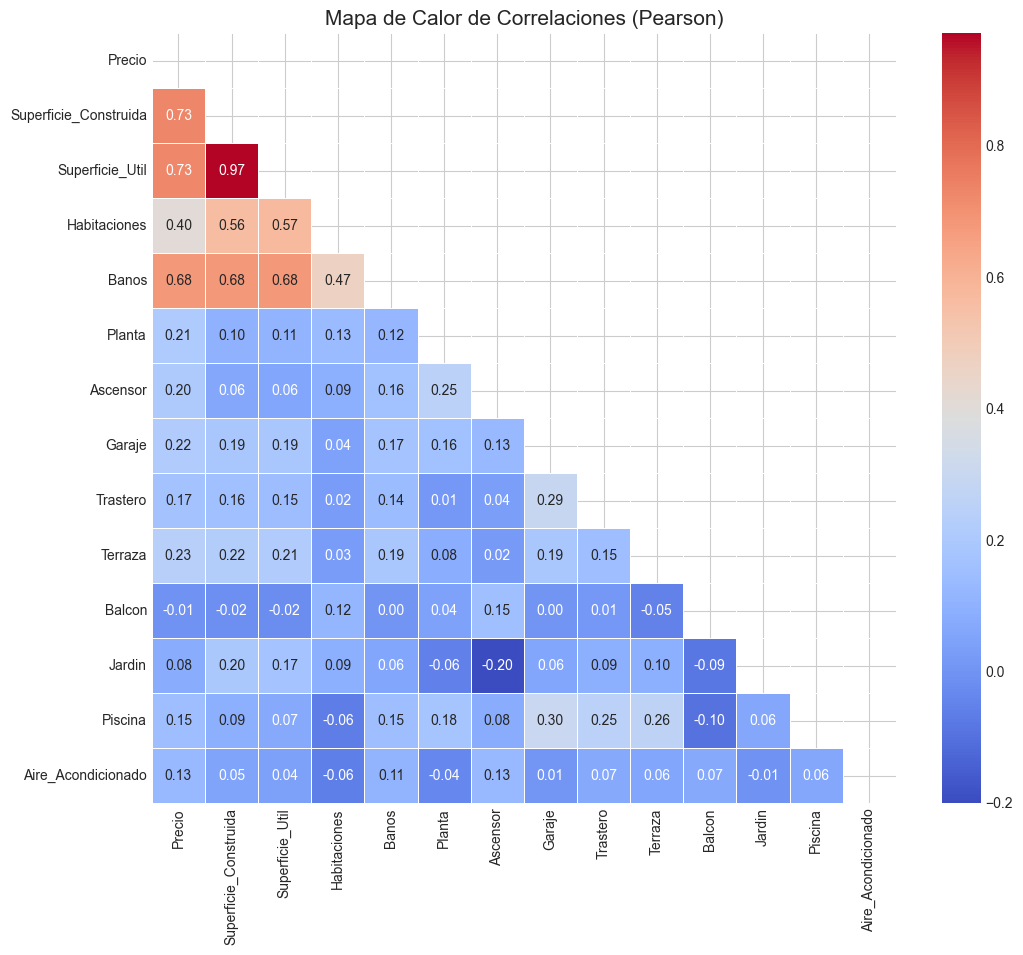


--- 🏘️ TOP 10 BARRIOS MÁS EXCLUSIVOS (€/m2) ---
Barrio
Valencia Capital Eixample               7100.33
Sant Francesc                           5662.01
El Pla Del Remei                        5659.76
Ciutat De Les Arts I De Les Ciencies    5601.29
Eixample                                5524.41
Eixample Gran Via                       5507.19
La Xerea                                5437.09
Quatre Carreres                         5387.86
Exposicio                               5304.09
Russafa                                 5277.38
Name: Precio_m2, dtype: float64


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 2. LIMPIEZA ESTRATÉGICA DE OUTLIERS
# Eliminamos los valores extremos que detectamos en el análisis descriptivo
df = df[df['Habitaciones'] <= 7]
df = df[df['Banos'] <= 6]
df = df[df['Superficie_Construida'] <= 500]
df = df[df['Precio'] <= 2500000]

# 3. PREPARACIÓN DE VARIABLES PARA CORRELACIÓN
columnas_binarias = ['Ascensor', 'Garaje', 'Trastero', 'Terraza', 'Balcon', 'Jardin', 'Piscina', 'Aire_Acondicionado']
df_num = df.copy()
for col in columnas_binarias:
    if col in df_num.columns:
        df_num[col] = df_num[col].map({'Sí': 1, 'No': 0})

# 4. ANÁLISIS DESCRIPTIVO (Resumen de salud del dataset)
vars_num = ['Precio', 'Superficie_Construida', 'Habitaciones', 'Banos', 'Planta']
print("--- 📊 RESUMEN ESTADÍSTICO TRAS LIMPIEZA ---")
display(df[vars_num].describe().round(2))

# 5. BLOQUE DE VISUALIZACIÓN
plt.style.use('seaborn-v0_8-whitegrid')

# A. Histogramas y Densidad (Distribuciones)
plt.figure(figsize=(18, 5))
for i, col in enumerate(vars_num, 1):
    plt.subplot(1, 5, i)
    sns.histplot(df[col], kde=True, color='teal', bins=20)
    plt.title(f'Distribución {col}')
plt.tight_layout()
plt.show()

# B. Boxplots (Detección visual de Outliers restantes)
plt.figure(figsize=(18, 5))
for i, col in enumerate(vars_num, 1):
    plt.subplot(1, 5, i)
    sns.boxplot(y=df[col], color='orange')
    plt.title(f'Boxplot {col}')
plt.tight_layout()
plt.show()

# C. Matriz de Correlación (Heatmap Profesional)
plt.figure(figsize=(12, 10))
corr_matrix = df_num.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) # Máscara para ver solo la mitad
sns.heatmap(corr_matrix, annot=True, mask=mask, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor de Correlaciones (Pearson)', fontsize=15)
plt.show()

# 6. ANÁLISIS EXTRA: PRECIO POR BARRIO
df['Precio_m2'] = df['Precio'] / df['Superficie_Construida']
ranking_barrios = df.groupby('Barrio')['Precio_m2'].mean().sort_values(ascending=False)

print("\n--- 🏘️ TOP 10 BARRIOS MÁS EXCLUSIVOS (€/m2) ---")
print(ranking_barrios.head(10).round(2))

In [3]:
# 7. GUARDADO DEL DATASET DEFINITIVO
# Este será el archivo que uses para entrenar la Inteligencia Artificial
df.to_csv('dataset_VALENCIA_FINAL_LIMPIO.csv', index=False, sep=';', decimal=',', encoding='utf-8-sig')

print("✅ ¡Archivo 'dataset_VALENCIA_FINAL_LIMPIO.csv' guardado con éxito!")

✅ ¡Archivo 'dataset_VALENCIA_FINAL_LIMPIO.csv' guardado con éxito!
